# **Atlántico**

El Atlántico es uno de los 32 departamentos que conforman la república de Colombia. Se encuentra conformado por 22 Municipios y el Distrito Especial Industrial y Portuario de Barranquilla, su capital.

Está situado al norte del territorio nacional, límita por el norte y noreste con el mar Caribe, en una extensión aproximada de 90 Km; desde el rompeolas occidental en Bocas de Ceniza, hasta las salinas de Galerazamba. Al este, con el río Magdalena, en una longitud de 105 Km, contados desde su desembocadura en Bocas de Ceniza hasta el desprendimiento del Canal del Dique en Calamar; al sur, suroeste y oeste con el departamento de Bolívar desde Calamar hasta las Salinas de Galerazamba.

Presenta un clima tropical de tipo estepa y sabana de carácter árido en la desembocadura del río Magdalena y alrededores de Barranquilla; semi-árido en las fajas aledañas al litoral y al río Magdalena y semihúmedo desde Sabanalarga hacia el sur.

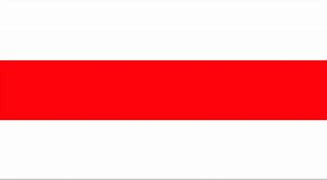

> Para el análisis se cuenta con 18,576 registros correspondientes a casos ocurridos en alguno de los 22 municipios del departamento del atlántico, representado en 21 variables, en el periodo del año 2017 al año 2023.


_____________

In [1]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from statsmodels.graphics.tsaplots import plot_acf

# Geoespacial
import geopandas as gpd
from libpysal.weights import Queen
import libpysal
from esda.moran import Moran, Moran_Local

# Estadística clásica y no paramétrica
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, shapiro
import scikit_posthocs as sp  # Pruebas post-hoc como Dunn

# Series temporales y detección de rupturas
import ruptures as rpt
from pymannkendall import original_test  # Tendencias en series temporales

In [2]:
# [Configuración] Leer data
df = pd.read_csv(r"C:\Users\Hp\DENGUE\DATA\Data_Atlantico.csv")

# Leer shapefile
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

semanas = pd.read_csv("Resumen/consolidado_atlantico.csv")

casos = pd.read_csv("Resumen/casos_mun_atlantico.csv")

poblacion = pd.read_csv("Poblacion/Poblacion_departamental.csv", encoding="latin_1")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18576 entries, 0 to 18575
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   sexo                   18576 non-null  object
 1   edad_años              18576 non-null  int64 
 2   ciclo_vital            18576 non-null  object
 3   grupo_etnico           18576 non-null  object
 4   regimen_salud          18576 non-null  object
 5   evento                 18576 non-null  object
 6   tipo_de_caso           18576 non-null  object
 7   hospitalizacion        18576 non-null  object
 8   desenlace              18576 non-null  object
 9   año                    18576 non-null  int64 
 10  semana                 18576 non-null  int64 
 11  periodo                18576 non-null  int64 
 12  fecha_inicio_sintomas  18576 non-null  object
 13  fecha_consulta         18576 non-null  object
 14  fecha_hospitalizacion  18576 non-null  object
 15  fecha_notificacion 

In [3]:
# [] Convertir fechas a DateTime
columnas_fecha = ["fecha_consulta", "fecha_inicio_sintomas", "fecha_notificacion", "fecha_nacimiento", "fecha_hospitalizacion"]

for col in columnas_fecha:
    df[col] = df[col].replace(["--", "  -   -", "-", " "], pd.NA)
    df[col] = pd.to_datetime(df[col], format='mixed')
    print(f"Columna '{col}' convertida a datetime.")

Columna 'fecha_consulta' convertida a datetime.
Columna 'fecha_inicio_sintomas' convertida a datetime.
Columna 'fecha_notificacion' convertida a datetime.
Columna 'fecha_nacimiento' convertida a datetime.
Columna 'fecha_hospitalizacion' convertida a datetime.


In [4]:
# [] Valores nulos por variable
faltantes = df.isnull().sum()
print("Valores faltantes por variable: \n")
print(faltantes[faltantes > 0])

Valores faltantes por variable: 

fecha_hospitalizacion    7706
fecha_nacimiento          525
localidad                3218
barrio                    244
direccion                   1
dtype: int64


## **1. Descriptivo de variables**

In [5]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(4)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")

### 2.1 Variables demográficas

In [6]:
print("DESCRIPCIÓN DE VARIABLES CATEGÓRICAS")
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])


DESCRIPCIÓN DE VARIABLES CATEGÓRICAS

📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adolescencia        7849      0.4225     7662    187        0.9762      0.0238
Adulto              4096      0.2205     3987    109        0.9734      0.0266
Infancia            4066      0.2189     3991     75        0.9816      0.0184
Primera infancia    1925      0.1036     1901     24        0.9875      0.0125
Adulto mayor         482      0.0259      462     20        0.9585      0.0415
Menor de 1 año       113      0.0061      112      1        0.9912      0.0088
Ancianidad            45      0.0024       43      2        0.9556      0.0444

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                                                                   
Masculino    9741      0.524

La población infectada por dengue en el Atlántico está en su mayoría, en edad adolescente (42.2%), seguida de población adulta (22.1%) e infantes (21.8%); estos grupos etarios son los de mayor exposición al estar en el medio educativo y laboral. Se resalta que para la población adulto mayor y ancianidad, se presentan una proporción más elevada de dengue grave, lo que manifiesta una mayor vulnerabilidad clínica en estas etapas. 

La distribución de casos por sexo es equilibrada, siento el 52.4% masculinos. En términos étnicos, solo un 2.17% de casos se asocia a pacientes pertenecientes a un grupo étnico. Los pacientes, en su mayoría están afiliados al régimen de salud subsidiado (53.5%) y contributivo (39.1%), no obstante, aunque la población de pacientes no asegurados representan apenas el 2.3% de los casos, concentran una mayor proporción de dengue grave (6.3%), lo que sugiere una posible asociación entre la ausencia de cobertura en salud y un peor desenlace clínico del dengue. 

In [7]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"], 
    categories=orden_ciclos_edad, 
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo, observed=True)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,1925,2.56,3.0,1.17,1.0,4.0,1,4
1,Infancia,4066,7.20,7.0,1.38,6.0,8.0,5,9
2,Adolescencia,7849,13.91,14.0,2.69,12.0,16.0,10,19
3,Adulto,4096,30.70,27.0,10.30,22.0,36.0,20,59
4,Adulto mayor,482,69.12,68.0,6.91,63.0,74.0,60,84
5,Ancianidad,45,89.38,88.0,3.89,86.0,91.0,85,101


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera: 

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 3 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 22-36 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -101 años]: Concentración de edades entre los 86-91 años. 

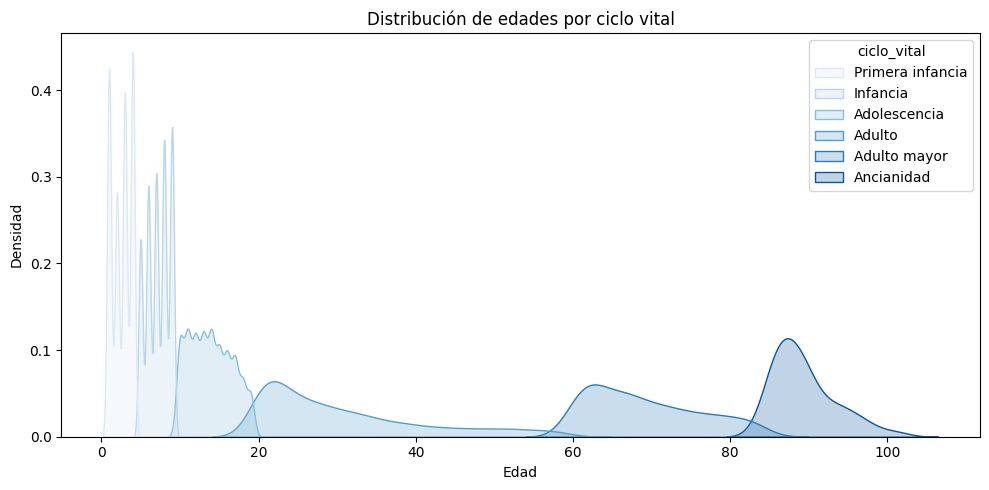

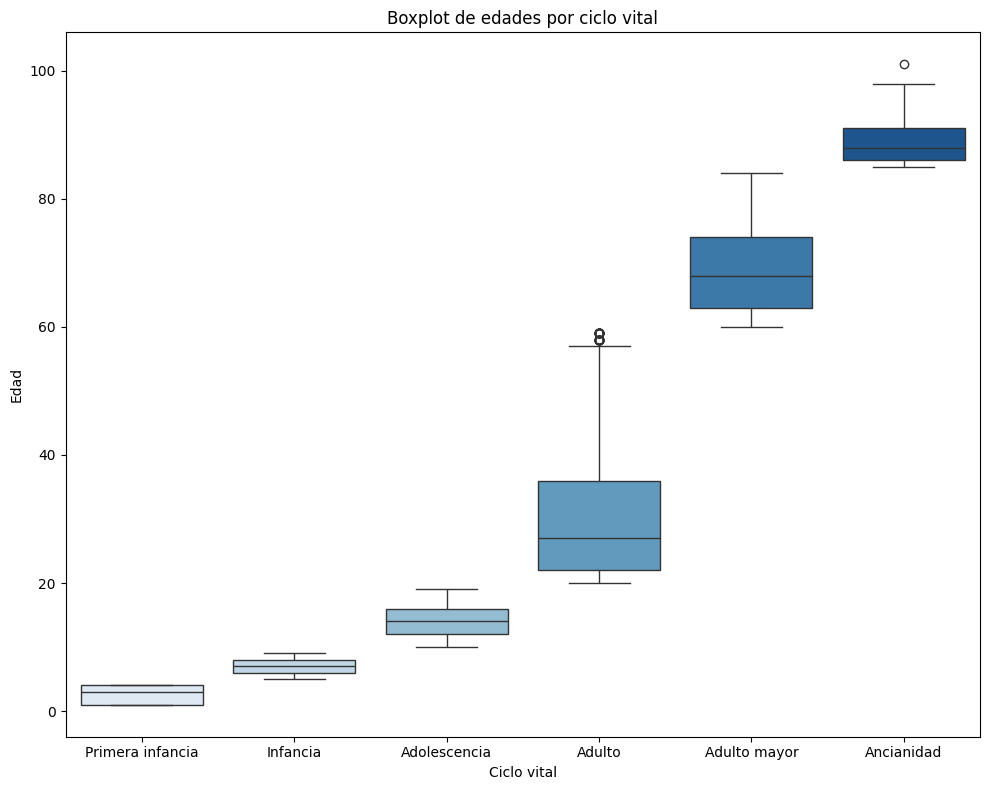

In [8]:
# [Gráfico] Distribución de edad
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True, palette="Blues")
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df, x=grupo, hue=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad.

### 2.2 Variables de evento



In [9]:
describir_categorica(df['evento'])
describir_categorica(df['tipo_de_caso'])
describir_categorica(df['hospitalizacion'])
describir_categorica(df['desenlace'])


📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico   18158      0.9775    18158      0           1.0         0.0
Grave       418      0.0225        0    418           0.0         1.0

-----------------------------------

📌 Variable: tipo_de_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_de_caso                                                              
Probable                13611      0.7327    13311    300         0.978   
Conf. por laboratorio    4912      0.2644     4794    118         0.976   
Conf. por nexo             53      0.0029       53      0         1.000   

                       Prop_Grave  
tipo_de_caso                       
Probable                    0.022  
Conf. por laboratorio       0.024  
Conf. por nexo              0.000  

-----------------------------------

📌 Variable: hospitalizacion
               

El dengue clásico en el Atlántico tiene una representatividad del 97.8% de casos (181,158) frente al 2.3% de casos graves (418) en todo el territorio. En su mayoría los registros analizados corresponden a casos probables (73.3%), solo el 26.4% fueron casos confirmados por prueba en laboratorio. Todos los casos confirmados por nexo epidemiológico (53) se relacionan al dengue clásico. 

De los casos registrados, se tiene que solo el 58.5% de los pacientes requirieron hospitalización, mientras que el 41.5% fueron manejados de manera ambulatoria. De los 418 casos de dengue grave, 10 no fueron hospitalizados. 

En relación a los fallecidos, la mortalidad registrada es mínima, existiendo solo 7 pacientes fallecidos, todos por dengue grave.

### 2.3 Variables espaciales

#### Casos netos

In [10]:
describir_categorica(df["area"])
describir_categorica(df['municipio'])


📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal   17839      0.9603    17437    402        0.9775   
Centro Poblado         644      0.0347      630     14        0.9783   
Rural disperso          93      0.0050       91      2        0.9785   

                    Prop_Grave  
area                            
Cabecera municipal      0.0225  
Centro Poblado          0.0217  
Rural disperso          0.0215  

-----------------------------------

📌 Variable: municipio
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
municipio                                                                     
SOLEDAD             8790      0.4732     8623    167        0.9810      0.0190
MALAMBO             2087      0.1123     2045     42        0.9799      0.0201
BARANOA             1206      0.0649     1186     20        0.9834      0.0166
S

In [11]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")

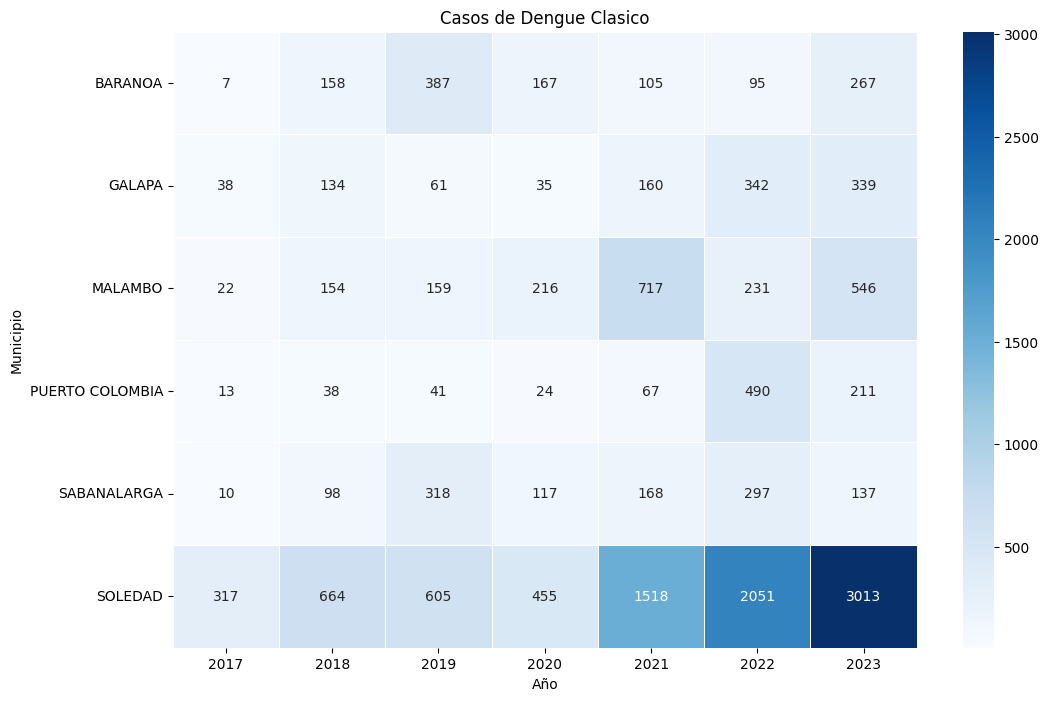

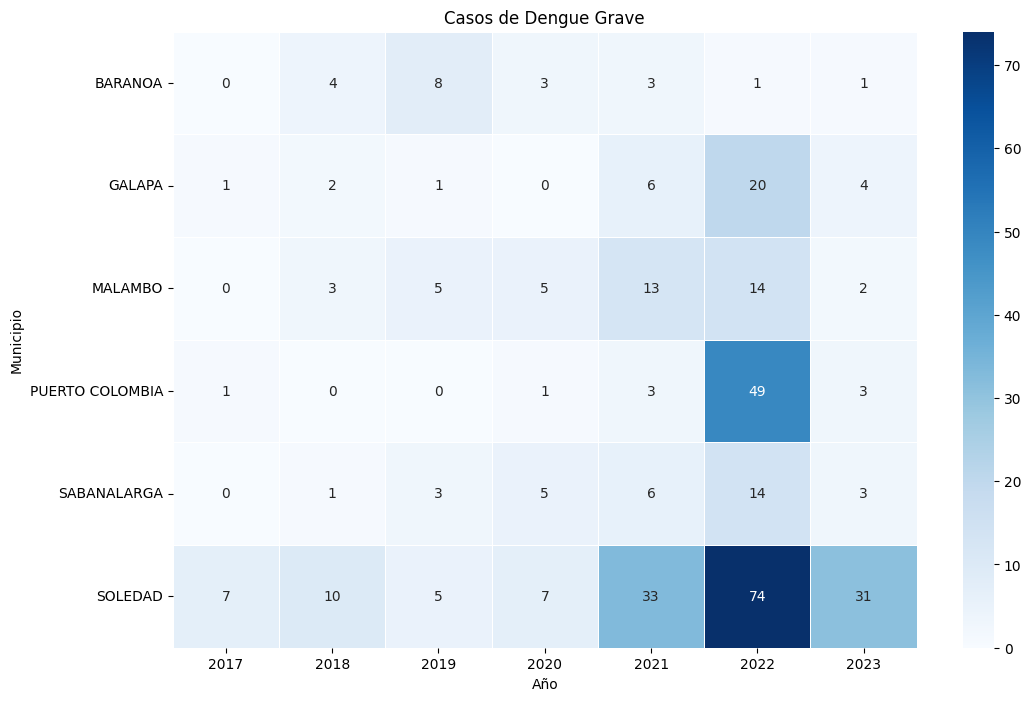

In [12]:
totales_mun = tabla_mun.groupby("municipio")["casos"].sum()
municipios_filtrados = totales_mun[totales_mun > 800].index
tabla_filtrada = tabla_mun[tabla_mun["municipio"].isin(municipios_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="municipio", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


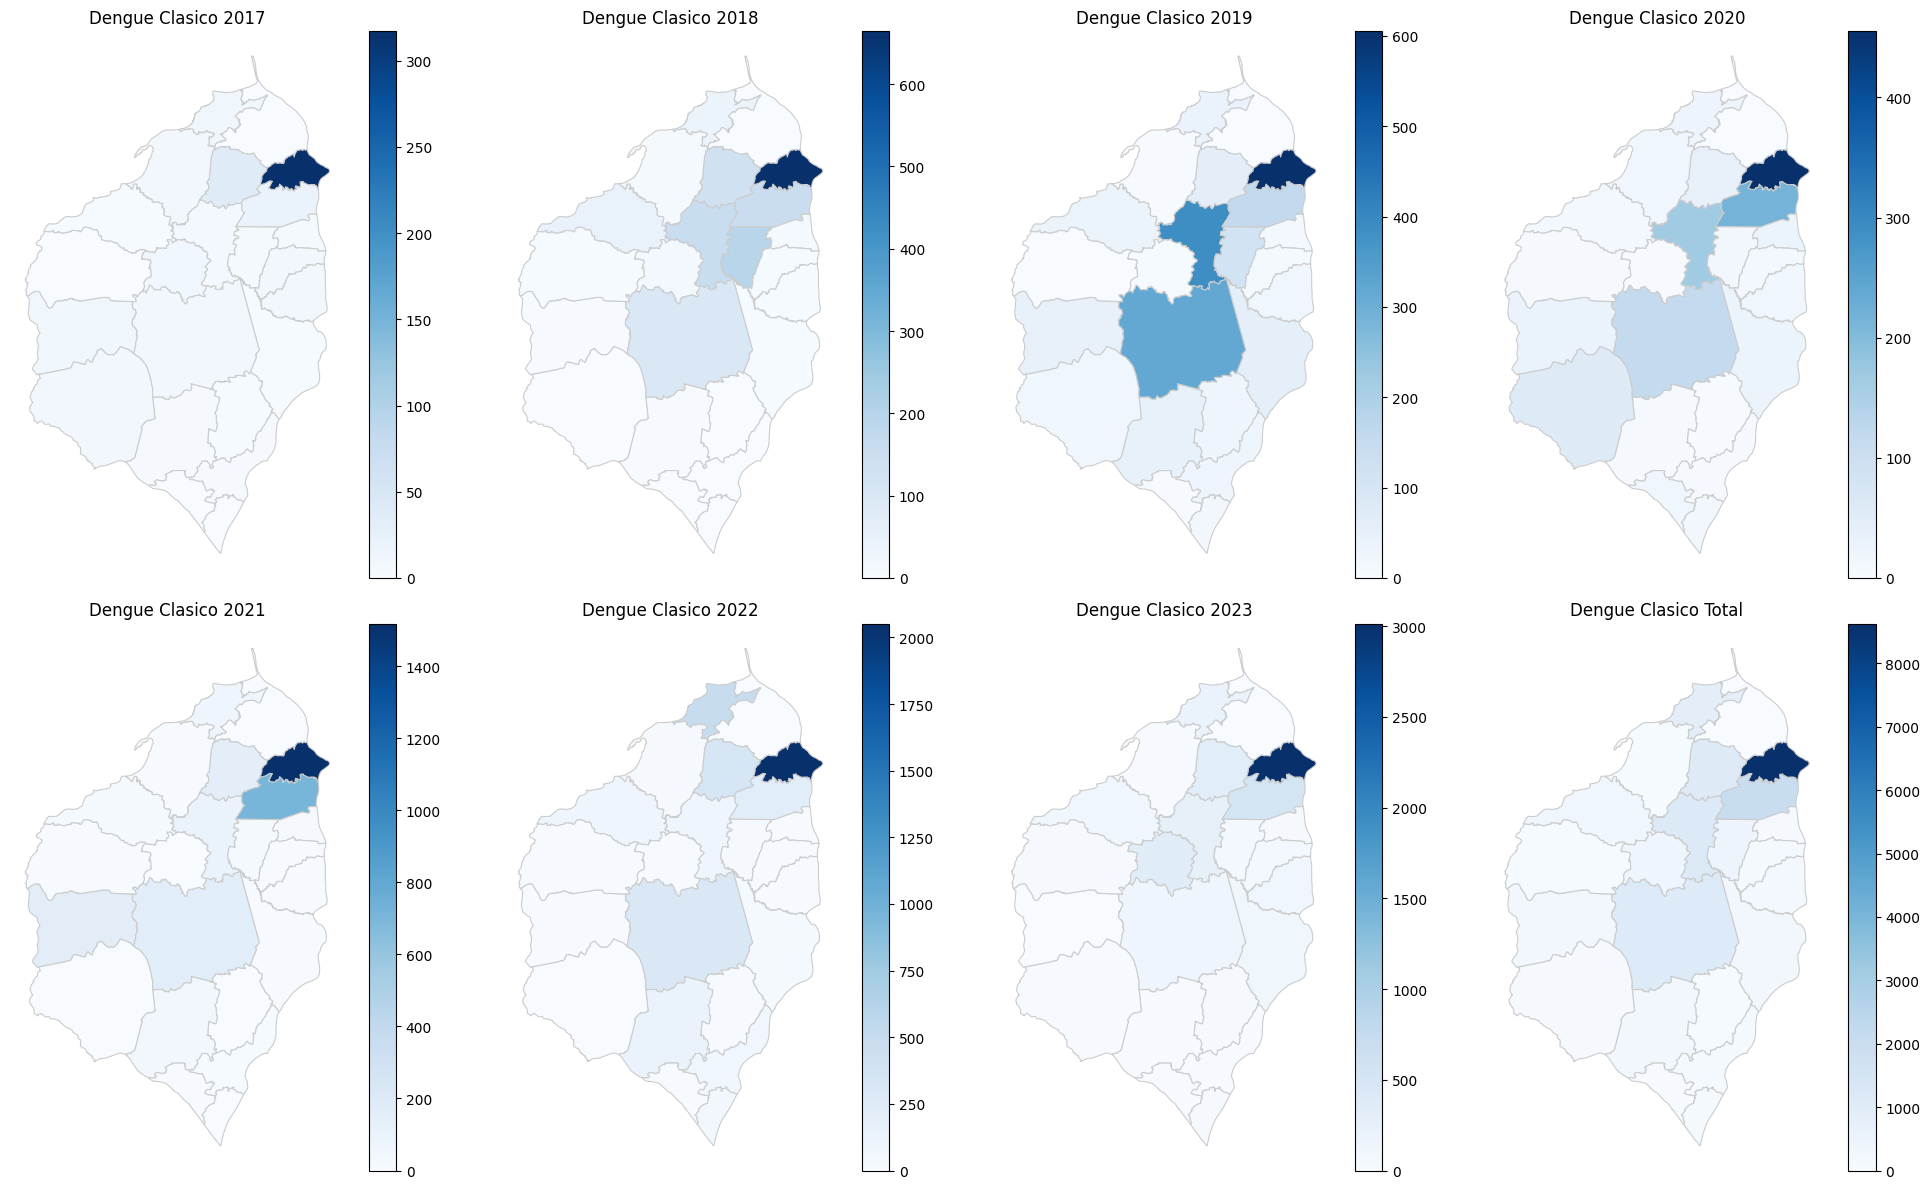

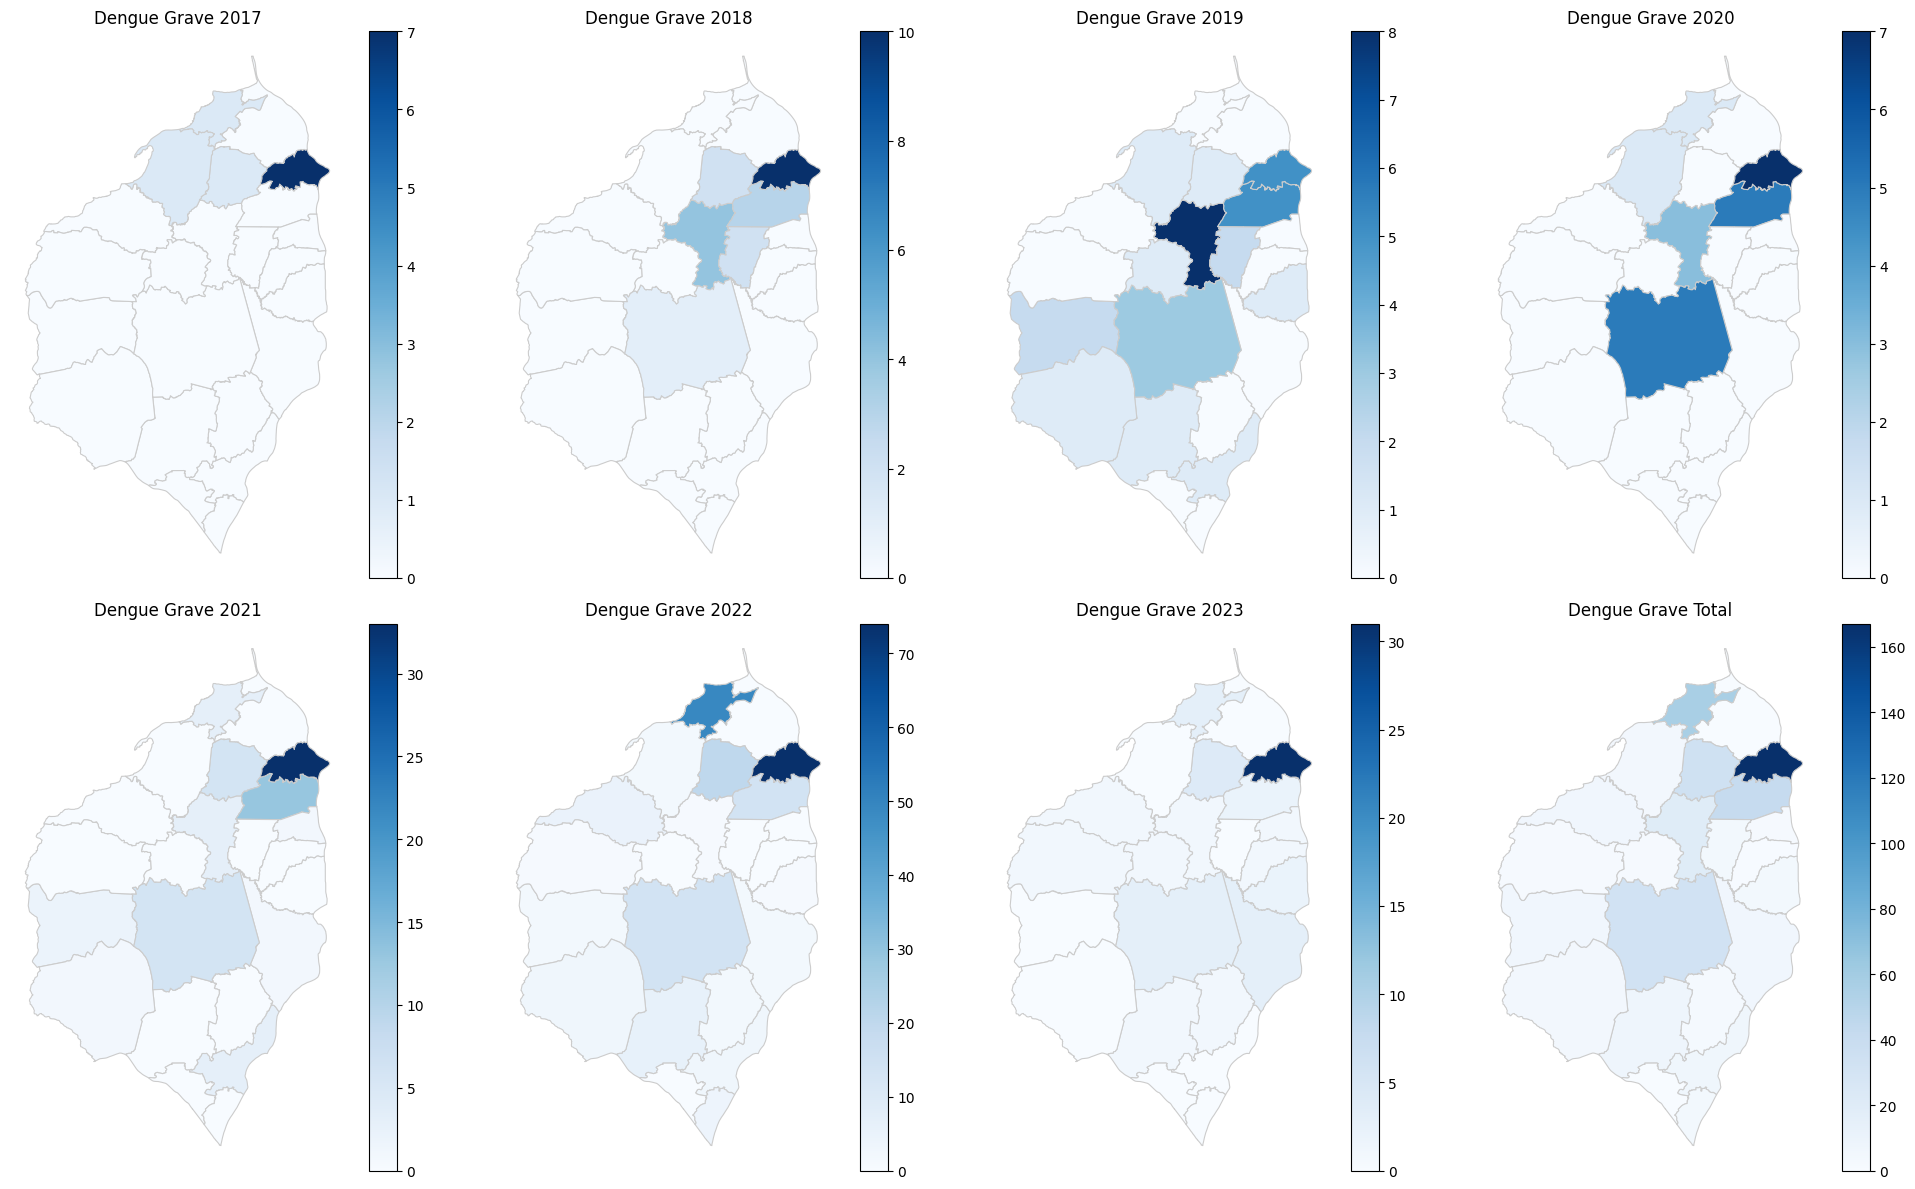

In [13]:
# [Gráfico] Mapa casos por municipio según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("municipio")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total por evento
    casos_total = (
        df[df["evento"] == evento]
        .groupby("municipio")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="municipio", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Total")
    axes[-1].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


Los casos de dengue se registraron en su mayoría en una cabecera municipal (96%), siendo solo el 4% en un centro poblado o rural disperso. 

La dinámica por municipios es variada, en datos netos, los municipios metropolitanos de Soledad y Malambo registran la mayor cantidad de casos de dengue clásico y grave. La mitad de los casos se concentra en el municipio de Soledad (47.3%) con 8,623 casos, de los cuales 167 son de dengue grave. 

Luego, los municipios de Baranoa, Sabanalarga y Galapa, constituyen un bloque de más de 1,000 casos reportados, representando cada uno un 6% del total de casos, conformando el núcleo de mayor transmisión. Cabe resaltar que en el municipio de Puerto Colombia, se registro la mayor cantidad de casos graves (57) después de Soledad. 

Con menor representatividad, sin superar los 100 registros, se encuentran los municipios de Candelaria, Piojó y Santa Lucía, este último, no presenta casos por dengue grave. 

En resumen, la epidemia de dengue en el departamento del Atlántico presenta un patrón predominante urbano, con concentración en los municipios del área metropolitana y céntrica, lo cual podría reflejar tanto características locales de transmisión como posibles diferencias en el acceso a diagnóstico oportuno.

#### Casos por densidad poblacional

In [14]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")

# Ajustar nombres de columna para unir
poblacion = poblacion.rename(columns={'MUNICIPIO':'municipio', 'TOTAL':'total_pob'})

# Convertir columnas de año en una columna 'año'
poblacion_long = poblacion.melt(
    id_vars=['municipio', 'total_pob'],    # mantener municipio y total
    value_vars=['2017.0','2018.0','2019.0','2020.0','2021.0','2022.0','2023.0'],
    var_name='año',
    value_name='poblacion'
)

# Asegurarse de que 'año' sea numérico
poblacion_long['año'] = poblacion_long['año'].astype(float).astype(int)

# Unir casos con población del mismo año
tabla_mun = tabla_mun.merge(poblacion_long, on=['municipio','año'], how='left')

# Densidad por año y municipio
tabla_mun['densidad'] = tabla_mun['casos'] / tabla_mun['poblacion']

# Si quieres por cada 1000 habitantes
tabla_mun['densidad'] = (tabla_mun['casos'] / tabla_mun['poblacion']) * 1000

tabla_mun = tabla_mun.sort_values(by='densidad', ascending=False)

In [15]:
# Densidad global por municipio (todos los años)
densidad_global = tabla_mun.groupby("municipio").agg(
    casos_totales=('casos', 'sum'),
    poblacion_total=('total_pob', 'first')   # la misma población total por municipio
).reset_index()

densidad_global['densidad_global'] = (densidad_global['casos_totales'] / densidad_global['poblacion_total']) * 10000

# Ordenar de mayor a menor
densidad_global = densidad_global.sort_values(by='densidad_global', ascending=False)

densidad_global.head(10)


,municipio,casos_totales,poblacion_total,densidad_global
22,USIACURÍ,400,107917.0,37.065523
11,POLONUEVO,447,155707.0,28.707765
0,BARANOA,1206,539600.0,22.349889
4,GALAPA,1143,519297.0,22.010526
13,PUERTO COLOMBIA,941,443890.0,21.198946
7,MALAMBO,2087,1105302.0,18.881717
5,JUAN DE ACOSTA,331,178618.0,18.531167
19,SOLEDAD,8790,5229151.0,16.809612
8,MANATÍ,264,171632.0,15.381747
16,SABANALARGA,1177,785276.0,14.988361


In [16]:
densidad_global['densidad_global'].describe()

count    22.000000
mean     14.429214
std       8.490318
min       3.947491
25%       7.047110
50%      14.324278
75%      18.794080
max      37.065523
Name: densidad_global, dtype: float64

<Axes: xlabel='densidad_global'>

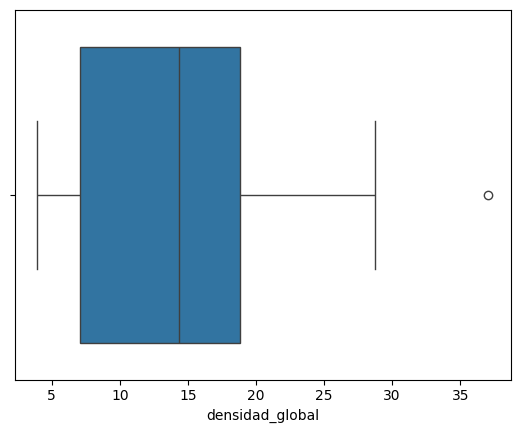

In [17]:
sns.boxplot(data=densidad_global, x='densidad_global')

La densidad poblacional de casos de dengue por municipio presenta una gran variabilidad. El valor promedio es de aproximadamente 14.3 casos por cada 10,000 habitantes, con una desviación estándar de 8.4 casos. Un 25% de los municipios reporta entre 7 a 14.3 casos, mostrando entonces la mitad de los territorios no reportan más de 15 casos por cada 10,000 habitantes. El municipio de Usiacurí es el de mayor densidad de casos (37), este es un dato atípico al conjunto, representando una tasa muy alta. La distribución de la densidad es sesgada hacia la derecha, con municipios de Polovuevo, Baranoa, Galapa y Puerto Colombia reportando más de 20 casos por cada 10,000 habitantes. 

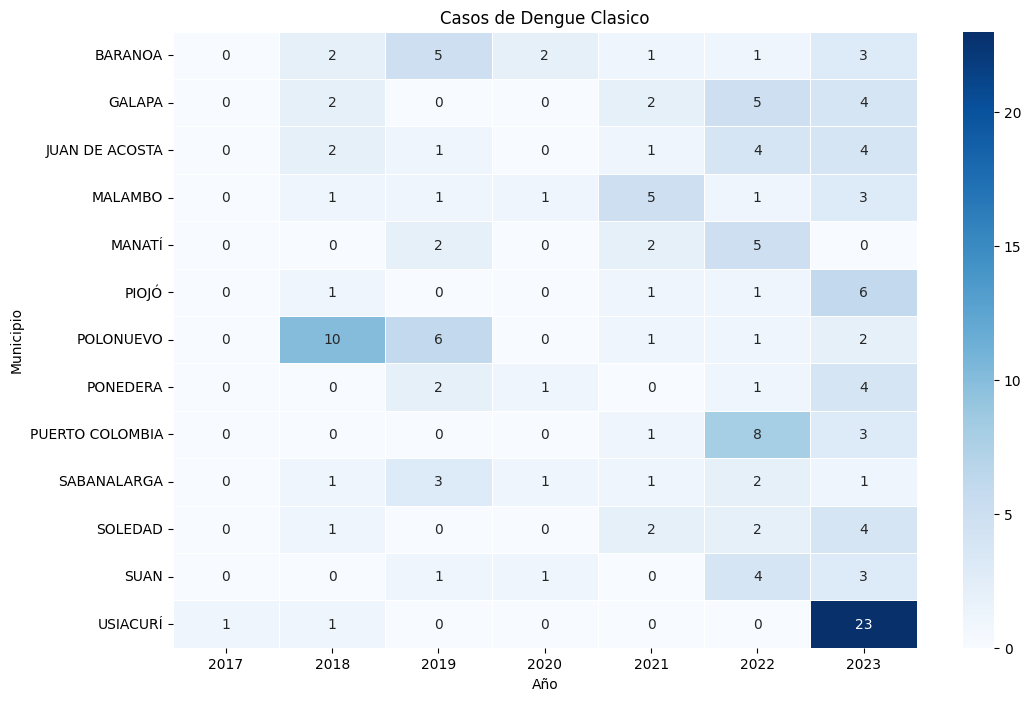

In [18]:
totales_mun = tabla_mun.groupby("municipio")["densidad"].sum()
municipios_filtrados = totales_mun[totales_mun > 10].index
tabla_filtrada = tabla_mun[tabla_mun["municipio"].isin(municipios_filtrados)]

eventos = ["Clasico"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]
    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="municipio", 
        columns="año", 
        values="densidad", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


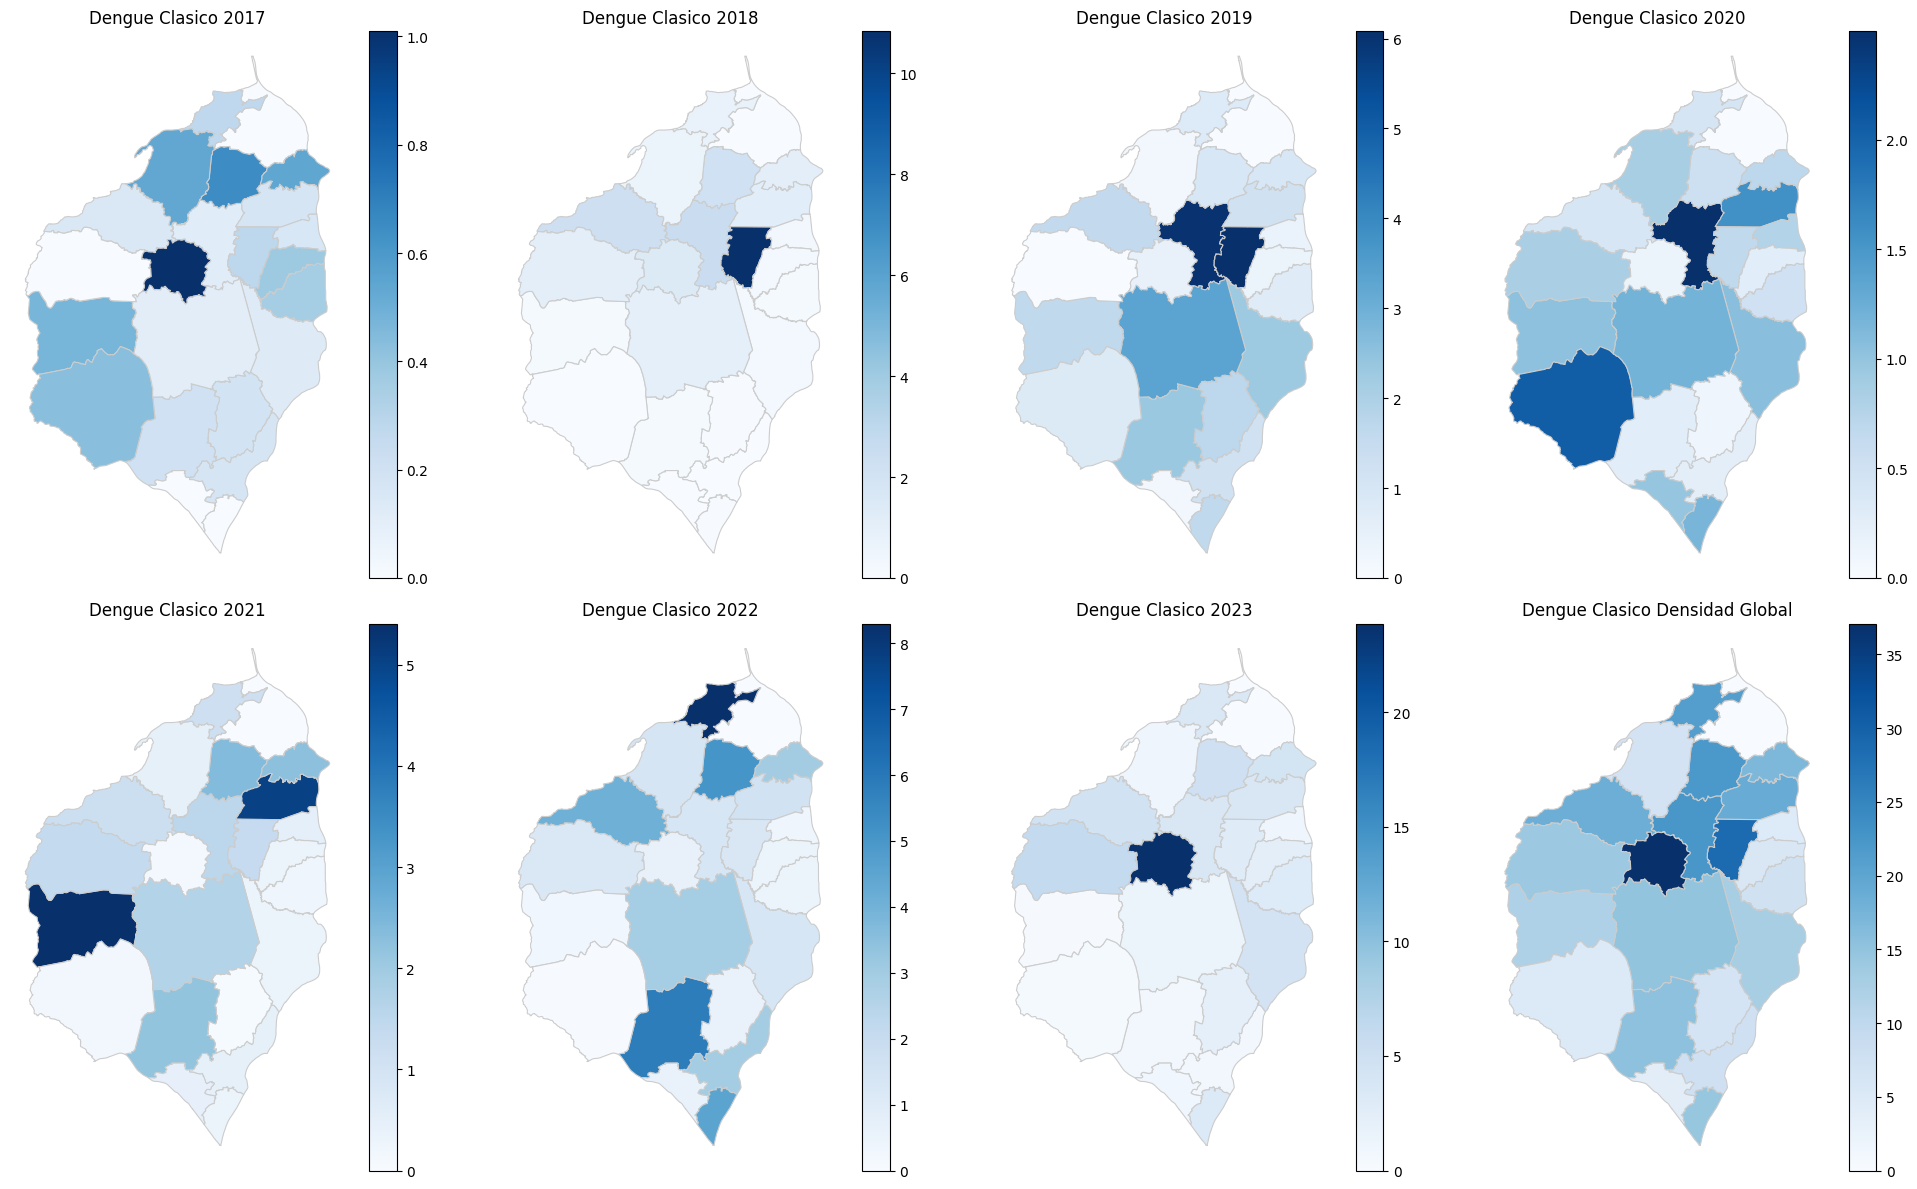

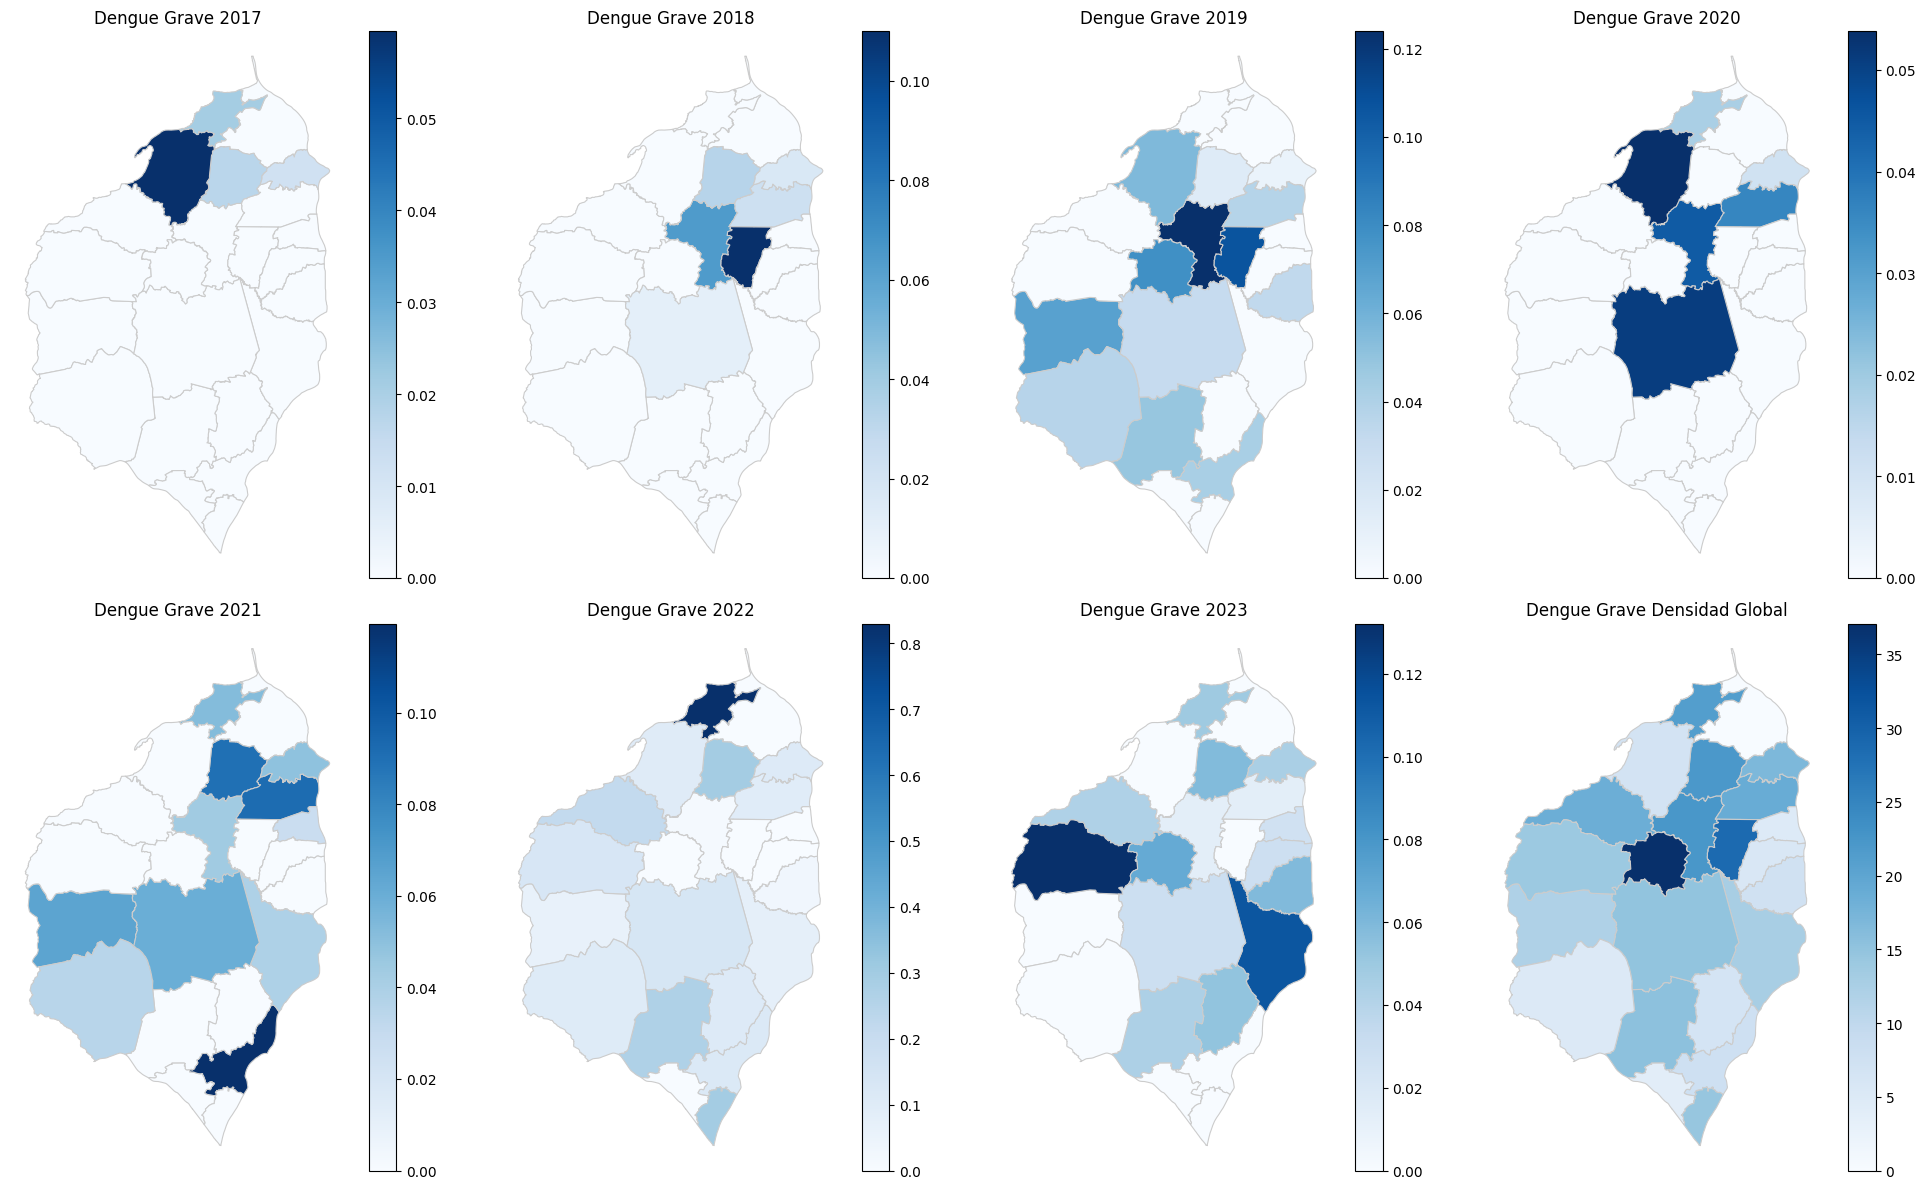

In [19]:
# [Gráfico] Mapa casos por municipio según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            tabla_mun[(tabla_mun["año"] == anio) & (tabla_mun["evento"] == evento)]
            .groupby("municipio")["densidad"].sum()   # sumar densidad por municipio
            .reset_index()
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="densidad", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    gdf_total = gdf.merge(densidad_global[['municipio','densidad_global']], on="municipio", how="left").fillna(0)
    gdf_total.plot(column="densidad_global", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Densidad Global")
    axes[-1].axis("off")


    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### 2.3 Variables temporales

In [20]:
describir_categorica(df["año"])


📌 Variable: año
      Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
año                                                               
2023    5665      0.3050     5609     56        0.9901      0.0099
2022    4257      0.2292     4054    203        0.9523      0.0477
2021    3171      0.1707     3099     72        0.9773      0.0227
2019    2063      0.1111     2031     32        0.9845      0.0155
2018    1613      0.0868     1591     22        0.9864      0.0136
2020    1295      0.0697     1273     22        0.9830      0.0170
2017     512      0.0276      501     11        0.9785      0.0215

-----------------------------------


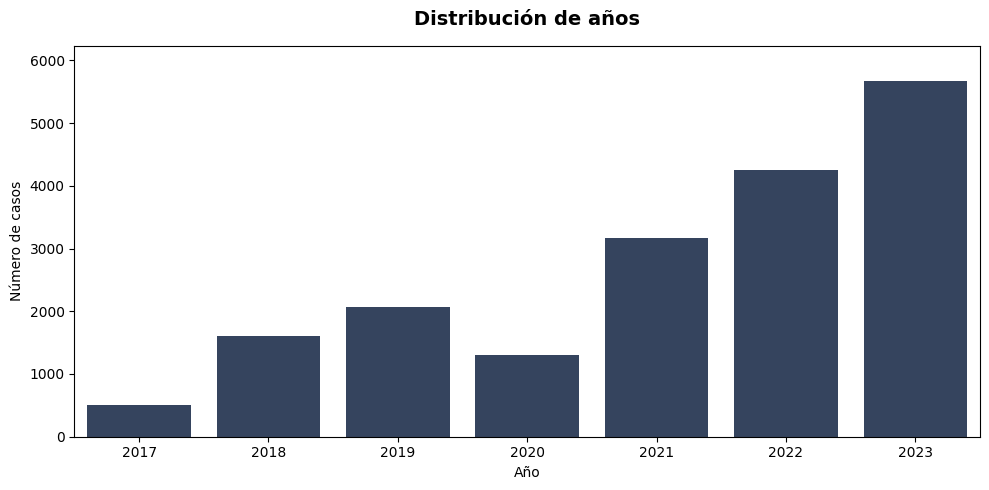

In [21]:
# [Gráfico] Distribución por años
conteo_por_año = df['año'].value_counts(sort=False).sort_index()

    # Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución de años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La variabilidad de los casos en el tiempo, muestra una notoria tendencia hacía la alza al pasar de los años, con variaciones importantes. Del 2017 al 2019, se obtienen la menor cantidad de registros, solo el 27% de los casos se dieron en este tiempo. En este periodo se evidencia un ciclo de crecimiento con caída hacia el 2020, para seguir la tendencia de crecimiento hacia el 2023. El año 2022, es el que mayor registro de casos de dengue grave presenta, unos 203 pacientes. 

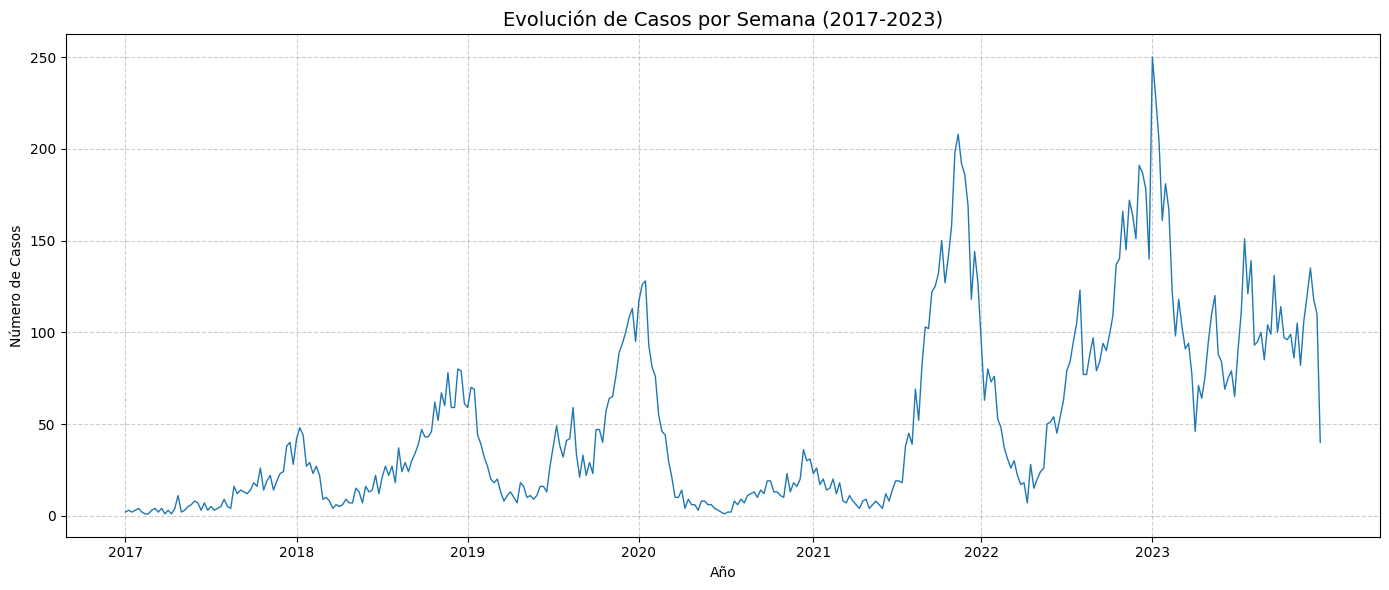

In [22]:
# [Gráfico] Casos por semana
casos_semana = df.groupby(["año", "semana"]).size().reset_index(name="casos")
casos_semana = casos_semana.sort_values(["año", "semana"]).reset_index(drop=True)
casos_semana["index"] = range(len(casos_semana))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_semana["index"], casos_semana["casos"], linewidth=1)
años_unicos = casos_semana["año"].unique()
ticks = [casos_semana[casos_semana["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por Semana (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [23]:
week = tabla_descriptiva(df_edad, variable="semana", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2017,505,38.36,42.0,12.61,33.0,49.0,1,52
1,2018,1604,33.51,39.0,16.24,24.0,47.0,1,52
2,2019,2050,32.72,38.0,16.97,21.0,47.0,1,52
3,2020,1287,17.04,7.0,18.23,3.0,35.0,1,53
4,2021,3157,39.97,43.0,11.15,37.0,47.0,1,52
5,2022,4245,33.81,38.0,15.08,26.0,46.0,1,52
6,2023,5615,24.39,25.0,16.10,8.0,38.0,1,52


C:\Users\Hp\AppData\Local\Temp\ipykernel_31940\1452467844.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos


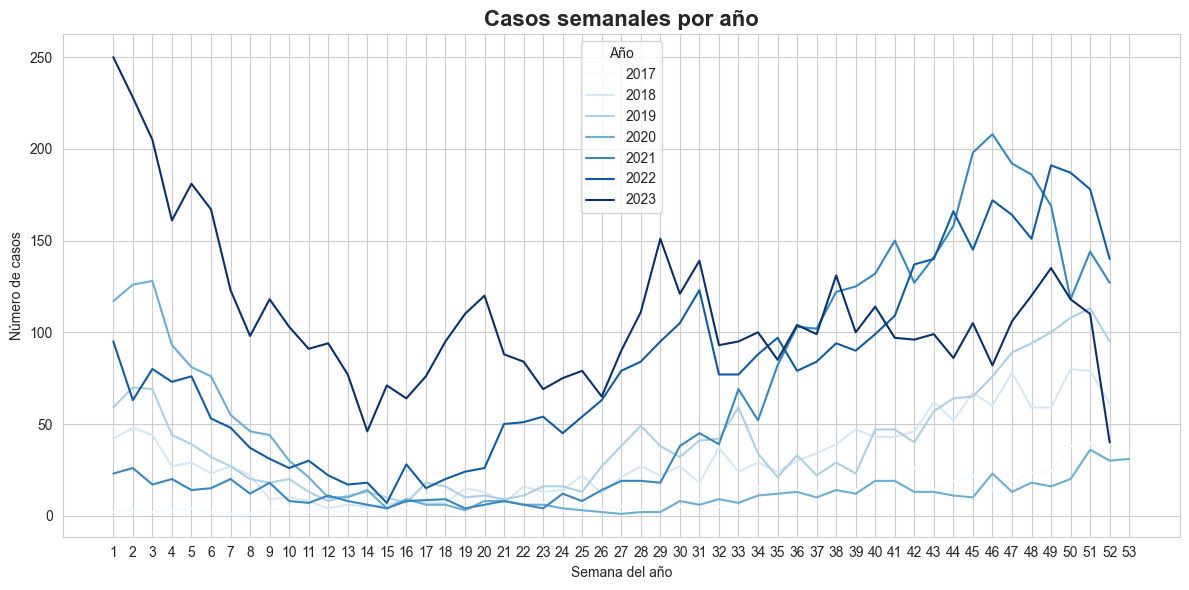

In [24]:
# Contar casos por semana y año
conteo_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')

def graficar_casos_semanales_por_año(df_conteo, nombre_grafico="Casos semanales por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())
    colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(datos_año['semana'], datos_año['casos'], 
                label=str(año), color=colores(i))
        
    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("Semana del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 54))  # Semanas ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()

graficar_casos_semanales_por_año(conteo_semanal)

Al detallar los registros por la semana epidemiológica, se evidencia que existe un aumento de casos hacia los últimos meses de cada año, con algunos picos hacia la mitad del año. 

En promedio, los casos se dan en su mayoría entre la semana 28 y la semana 44, con una media de distribución hacia la semana 30. Se destaca que el record de casos fue de 250 en la primera semana del 2023.

Con respecto a cada año, la mayor variabilidad se evidencia en el 2023. Los años 2021 y 2022, presentan notados picos de alza hacia finales de cada año. El 2017 y el 2020, son los años de manor variabilidad.

## **2. Exploración binaria**

In [25]:
demograficas = [
    "sexo",                    # M/F
    "edad_años",               # Edad numérica
    "ciclo_vital",             # Etapa de vida
    "grupo_etnico",            # Grupo étnico declarado
    "regimen_salud"            # Régimen (contributivo, subsidiado, etc.)
]

    # Variables del evento epidemiológico
evento = [
    "evento",                  # Clásico, grave
    "tipo_de_caso",               # Confirmado, probable, descartado
    "hospitalizacion",         # Sí/No
    "desenlace"                # Recuperado, fallecido, etc.
]

    # Variables de temporalidad
temporalidad = [
    "año",                     # Año del evento
    "semana",                  # Semana epidemiológica
    "periodo",                 # Periodo (cada 4 semanas)
    "fecha_inicio_sintomas",   # Inicio de síntomas
    "fecha_consulta",          # Fecha de consulta
    "fecha_hospitalizacion",   # Fecha de hospitalización
    "fecha_notificacion",      # Fecha de notificación
    "fecha_nacimiento"         # Fecha de nacimiento
]

    # Variables espaciales
espacial = [
    "municipio"                # Municipio de ocurrencia
    "area",                    # Urbana o rural
    "localidad",                # Localidad (si aplica)
    "direccion"                # Dirección (si aplica)
    "barrio"                    # Barrio (si aplica)

]

In [26]:
# [Test] Prueba de Chi-Cuadrado
def matriz_pvalores(df, variables, alpha=0.05):
    matriz = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            if var1 == var2:
                matriz.loc[var1, var2] = "-"
            else:
                tabla = pd.crosstab(df[var1], df[var2])
                if tabla.shape[0] > 1 and tabla.shape[1] > 1:
                    chi2, p, dof, exp = chi2_contingency(tabla)
                    matriz.loc[var1, var2] = round(p, 4)
                else:
                    matriz.loc[var1, var2] = None
    return matriz

In [27]:
# [Test] Prueba de Chi-cuadrado por categoría
def chi_por_categoria(df, variable_referencia, variables_comparar, alpha=0.05):
    categorias = df[variable_referencia].dropna().unique()
    resultados = []

    for categoria in categorias:
        fila = {"Categoría": categoria}
        for var in variables_comparar:
            if var == variable_referencia:
                fila[var] = "-"
                continue

            # Grupo A = categoría específica vs resto
            df_temp = df.copy()
            df_temp["grupo_vs_resto"] = df_temp[variable_referencia].apply(
                lambda x: categoria if x == categoria else f"No {categoria}"
            )

            tabla = pd.crosstab(df_temp["grupo_vs_resto"], df_temp[var])
            _, p, _, _ = chi2_contingency(tabla)
            test = "Chi²"

            simb = "★" if p <= alpha else ""
            fila[var] = f"{round(p,4)} {simb}"
        resultados.append(fila)

    return pd.DataFrame(resultados)

### Variables demográficas

In [28]:
demograficas_c = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud"]

In [29]:
matriz_demo = matriz_pvalores(df[demograficas_c], demograficas_c)
matriz_demo

,sexo,ciclo_vital,grupo_etnico,regimen_salud
sexo,-,0.0,0.2438,0.0
ciclo_vital,0.0,-,0.4876,0.0
grupo_etnico,0.2438,0.4876,-,0.0
regimen_salud,0.0,0.0,0.0,-


La independencia entre variables demográficas, indica que el ciclo_vital y el regimen de salud están significativamente asociados al sexo de los pacientes, es decir, que la distribución de la edad y la afiliación al sistema de salud varía según el sexo. El regimen de salud está fuertemente asociado con todas las demás variables, siendo esta la más dependiente. Estas asociaciones reflejan patrones de desigualdad o segmentación en la población según características demográficas.

In [30]:
tabla_sexo = chi_por_categoria(df, "sexo", demograficas_c)
tabla_sexo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Masculino,-,0.0 ★,0.2438,0.0 ★
1,Femenino,-,0.0 ★,0.2438,0.0 ★


In [31]:
tabla_ciclo = chi_por_categoria(df, "ciclo_vital", demograficas_c)
tabla_ciclo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Adolescencia,0.0 ★,-,0.7207,0.0 ★
1,Infancia,0.0 ★,-,0.088,0.0005 ★
2,Adulto,0.1157,-,0.5122,0.0 ★
3,Adulto mayor,0.6273,-,0.1002,0.0004 ★
4,Primera infancia,0.4713,-,0.5287,0.195
5,Menor de 1 año,0.5399,-,0.6423,0.0 ★
6,Ancianidad,0.1277,-,0.991,0.0227 ★


In [32]:
tabla_salud = chi_por_categoria(df, "regimen_salud", demograficas_c)
tabla_salud

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Subsidiado,0.0 ★,0.0 ★,0.0 ★,-
1,Contributivo,0.0052 ★,0.0 ★,0.0 ★,-
2,Especial,0.2593,0.089,0.981,-
3,Excepción,0.0 ★,0.1484,0.0542,-
4,No asegurado,0.789,0.0017 ★,0.0002 ★,-
5,Indeterminado,1.0,0.0251 ★,0.9738,-


Para cada categoría dentro de las variables se destaca las etapas de vida no se distribuyen igual entre femeninas y masculinos, y el tipo de afiliación al sistema de salud varía entre sexos. 

En casi todas las etapas de vida, el régimen de salud varía notablemente. En la adolescencia y la infancia, la proporción de hombres y mujeres varía.

El régimen de salud esta fuertemente asociado a las demás variables demográficas, con diferencias marcadas para la población subsidiada y contributiva. 

In [33]:
categoricas = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud", 
                "tipo_de_caso", "hospitalizacion","desenlace"]
tabla_evento = chi_por_categoria(df, "evento", demograficas_c)
tabla_evento

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Clasico,1.0,0.0003 ★,0.402,0.0 ★
1,Grave,1.0,0.0003 ★,0.402,0.0 ★


La prueba de Chi-Cuadrado de independencia entre el evento de dengue y las variables demográficas muestra que ambos casos de evento están significativamente relacionados a la edad y al régimen de salud.

### Variables de evento

In [34]:
matriz_eve= matriz_pvalores(df[evento], evento)
matriz_eve

,evento,tipo_de_caso,hospitalizacion,desenlace
evento,-,0.393,0.0,0.0
tipo_de_caso,0.393,-,0.0,0.756
hospitalizacion,0.0,0.0,-,0.756
desenlace,0.0,0.756,0.756,-


Con respecto a las variables relacionadas con el evento epidemiológico, se observa que la hospitalización y desenlace están significativamente asociados con el evento. Además, la hospitalización y el tipo de caso tienen una asociación significativa, lo que sugiere que los casos confirmados o probables tienen diferente propensión a ser hospitalizados. 

### Variables temporales

In [35]:
# [Test] Shapiro para normalidad
stat, p = shapiro(semanas['total_casos'])
print(f"Estadístico={stat:.3f}, p-valor={p:.4f}")


Estadístico=0.849, p-valor=0.0000


Los casos de dengue por semana, de acuerdo a la prueba shapiro, no siguen una distribución normal.

In [36]:
# [Test] Kruskall Wallys para correspondencia
def comparar_casos_por_año(df, num_var='casos', cat_var='año', alpha=0.05):

    grupos = [df[df[cat_var]==g][num_var] for g in df[cat_var].unique()]
    
    # Kruskal-Wallis
    stat, p = kruskal(*grupos)
    kruskal_res = pd.DataFrame({
        'Estadístico': [stat],
        'p-valor': [p],
        'Significativo': ["★" if p <= alpha else ""]
    })
    
    # Post-hoc Dunn (solo si hay más de 2 grupos)
    if len(df[cat_var].unique()) > 2:
        posthoc = sp.posthoc_dunn(df, val_col=num_var, group_col=cat_var, p_adjust='bonferroni')
    else:
        posthoc = None
    
    return {'kruskal': kruskal_res, 'posthoc': posthoc}


resultados = comparar_casos_por_año(semanas, num_var='total_casos', cat_var='año')

print("Kruskal-Wallis:")
resultados['kruskal']

Kruskal-Wallis:


,Estadístico,p-valor,Significativo
0,171.980016,1.709937e-34,★


In [37]:
print("\nDunn post-hoc (p-valores corregidos Bonferroni):")
resultados['posthoc']


Dunn post-hoc (p-valores corregidos Bonferroni):


,2017,2018,2019,2020,2021,2022,2023
2017,1.000000e+00,1.696668e-04,6.715088e-07,2.942825e-01,8.032218e-08,3.512154e-18,8.487212e-28
2018,1.696668e-04,1.000000e+00,1.000000e+00,8.951510e-01,1.000000e+00,1.025256e-04,3.378912e-10
2019,6.715088e-07,1.000000e+00,1.000000e+00,4.069308e-02,1.000000e+00,9.675433e-03,2.989544e-07
2020,2.942825e-01,8.951510e-01,4.069308e-02,1.000000e+00,1.074953e-02,7.602006e-10,2.949031e-17
2021,8.032218e-08,1.000000e+00,1.000000e+00,1.074953e-02,1.000000e+00,4.101027e-02,3.113899e-06
2022,3.512154e-18,1.025256e-04,9.675433e-03,7.602006e-10,4.101027e-02,1.000000e+00,6.334551e-01
2023,8.487212e-28,3.378912e-10,2.989544e-07,2.949031e-17,3.113899e-06,6.334551e-01,1.000000e+00


La comparación del número de casos por semana entre los años 2017 y 2023 usando Kruskal-Wallis mostró una diferencia estadísticamente significativa (H = 171.98, p ≪ 0.001), indicando que la distribución de casos varió a lo largo del tiempo. El análisis post-hoc Dunn con corrección Bonferroni reveló que muchos años difieren significativamente entre sí; por ejemplo, 2017 presenta diferencias con 2018, 2019, 2022 y 2023, mientras que no difiere significativamente de 2020. En general, los años más recientes (2022 y 2023) muestran cambios marcados respecto a años anteriores, reflejando que la dinámica de los casos no fue constante y que ciertos periodos experimentaron aumentos o disminuciones significativas en la incidencia semanal. Esto evidencia una variación temporal clara en la distribución de casos a lo largo de los años.

In [38]:
# [Test] Mann-Kendall para los la tendencia
mann_kendall = original_test(semanas['total_casos'])

signal = semanas['total_casos'].values
algo = rpt.Pelt(model="rbf").fit(signal)
breaks = algo.predict(pen=10)


In [39]:
print(mann_kendall)
print(breaks)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.044571276042761), Tau=np.float64(0.4579511397693216), s=np.float64(30255.0), var_s=np.float64(5379055.0), slope=np.float64(0.26143790849673204), intercept=np.float64(-18.450980392156865))
[85, 165, 240, 364]


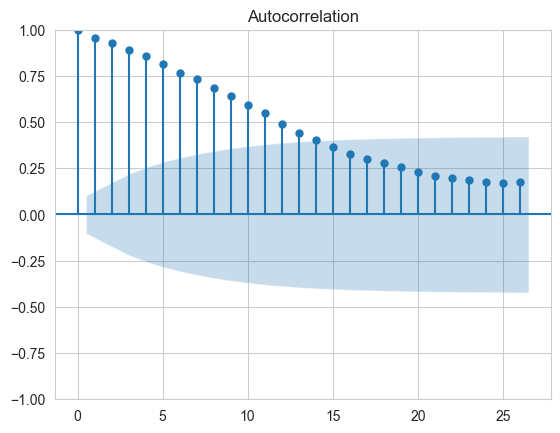

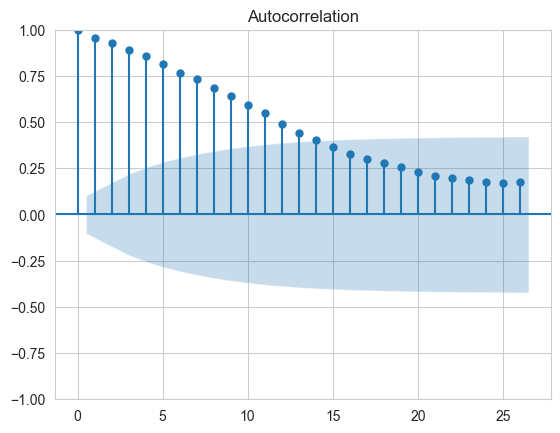

In [40]:
# [Gráfico] ACF de serie temporal
plot_acf(semanas['total_casos'])

De acuerdo con la prueba Mann-Kendall para evaluar la tendencia monotónica en el total de casos por semana epidemiológica, la serie muestra una tendencia creciente a lo largo del tiempo, rechazando la hipótesis nula de que no sigue una tendencia. El valor de correlación de Kendall indica una moderada-fuerte relación monotónica positiva (constante creciente). La mediana del cambio por semana es aproximadamente 0.26 casos adicionales por semana. De esta manera, la prueba indica que el número de casos semanales ha aumentado significativamente de manera consistente a lo largo de los años. 

El análisis de cambio estructural (breakpoint) indica que al rededor de la semana 85 (en este caso finales del 2018) hay un cambio abrupto en la media varianza de casos. Lo mismo en la semana 165, que corresponde a una de las primeras semanas del 2020. Luego en la semana 240 (finales del 2021) se tiene otro de los cambios abruptos. El último cambio estructural es la semana 364, es decir, la primera semana del año 2023. Esta variación indica que la serie no solo tiene una tendencia creciente, sino que también existen periodos donde la dinámica cambia abruptamente, lo que indica periodos de mayor brotes o años con mayor incidencia.

De acuerdo a la función de autocorrelación ACF, la serie tiene una Autocorrelación positiva decreciente, es decir, que los valores de semanas cercanas están correlacionados, y la correlación disminuye gradualmente a medida que aumenta el lag,  esto indica que los casos dependen de semanas anteriores. La autocorrelación es significativa hasta ~15 semanas. El decaimiento gradual sugiere un una tendencia. Esto indica que para las semanas cercanas, el número de casos es cercano, reflejando la forma en que la enfermedad se propaga en el tiempo.


### Variables espaciales

In [41]:
# [Test] Índice de Moran

#Unir con la geometría
muni = gdf.merge(casos, on="municipio")

# Crear matriz de pesos contiguos
w = Queen.from_dataframe(muni, use_index=False)
w.transform = "r"  #

y = muni['total_casos'].values
moran = Moran(y, w)

print("Índice de Moran:", moran.I)
print("Valor-p:", moran.p_sim)


Índice de Moran: 0.1705486844015851
Valor-p: 0.002


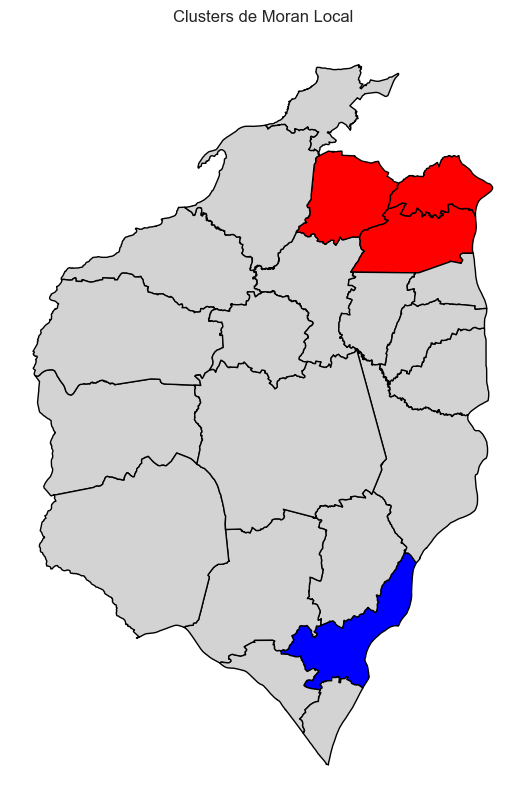

In [42]:
# Contiguos

# Crear matriz de pesos (Queen contiguidad)
w = libpysal.weights.Queen.from_dataframe(muni, use_index=False)
w.transform = "r"
moran_loc = Moran_Local(y, w)

# Signo de Moran local: High-High, Low-Low, Low-High, High-Low
muni['HH'] = (moran_loc.q==1) & (moran_loc.p_sim < 0.05)  # High-High
muni['LL'] = (moran_loc.q==3) & (moran_loc.p_sim < 0.05)  # Low-Low
muni['HL'] = (moran_loc.q==2) & (moran_loc.p_sim < 0.05)  # High-Low
muni['LH'] = (moran_loc.q==4) & (moran_loc.p_sim < 0.05)  # Low-High

# Crear una columna con el tipo de cluster
def cluster_label(row):
    if row['HH']: return 'High-High'
    elif row['LL']: return 'Low-Low'
    elif row['HL']: return 'High-Low'
    elif row['LH']: return 'Low-High'
    else: return 'No Signif'

muni['cluster'] = muni.apply(cluster_label, axis=1)

# Definir colores
colors = {
    'High-High':'red',
    'Low-Low':'blue',
    'High-Low':'orange',
    'Low-High':'lightgreen',
    'No Signif':'lightgrey'
}

# Graficar mapa
fig, ax = plt.subplots(1, 1, figsize=(10,10))
muni.plot(color=muni['cluster'].map(colors), edgecolor='black', ax=ax)
plt.title("Clusters de Moran Local")
plt.axis('off')
plt.show()

El índice de moran indica autocorrelación positiva moderada, es decir, que en los municipios con muchos casos tienden a estar cercanos entre sí, pero no es fuerte. Con el valor-p (0.009) se puede afirmar de que los casos se agregan especialmente en algunos municipios; es decir, los municipios con más casos tienden a estar cerca unos de otros. En el mapa se identifica el cluster de mayor foco de casos en los municipios de Soledad, Malambo y Galapa. El coldspots se identifica en el municipio de Santa Lucía.